**BASIC IMPORTS + BASIC Numpy and Matplotlib.**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from torch.onnx._internal.fx import passes
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 -4*x + 5

In [3]:
f(3.0)

20.0

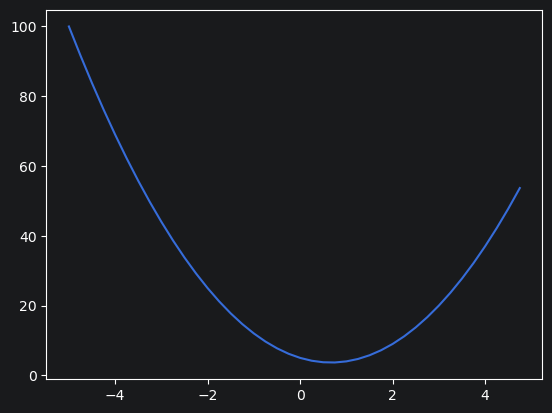

In [4]:
xs = np.arange(-5, 5, 0.25)
xs
ys = f(xs)
ys
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 3.0
f(x)
f(x + h) #this tells us if the function grows or goes down when we nudge x into the positive direction
(f(x + h) - f(x)) #this tells us how much the function responds to that x variation
(f(x + h) - f(x)) / h # the variation normalized by h, a numerical approximation of the slope, the smaller the h, the more accurate the slope; in this case, it is around 14.
#If we tried it on -3.0, the derivative would be negative, as we can see on the graphical representation of the function

14.00300000000243

In [6]:
#a bit more complex
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [7]:
#now, we will look at the derivatives of d with respect to a,b and c
h = 0.00001
#inputs
a = 2.0
b = -3.0
c = 10.0
d1 = a * b + c

a += h
d2 = a * b + c
print("d1 =", d1)
print("d2 =", d2)
print("Slope", (d2 - d1) / h) #We can verify that te result is correct by differentiating the function respect to a, as the result would be the value of b, which in this case is -3.0.

a = 2.0
b = -3.0
c = 10.0
b += h
d3 = a * b + c
print("d2 =", d3)
print("Slope", (d3 - d1) / h)

a = 2.0
b = -3.0
c = 10.0
c += h
d4 = a * b + c
print("d2 =", d4)
print("Slope", (d4 - d1) / h)

d1 = 4.0
d2 = 3.9999699999999994
Slope -3.000000000064062
d2 = 4.00002
Slope 2.0000000000131024
d2 = 4.00001
Slope 0.9999999999621422


In [128]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 #we assume it's 0 because every value doesn't affect the value
        self._backward = lambda: None #una función que no hace nada
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #so we can add up straight integers, this will only work if we do a * 2, not if we do 2 * a
        output = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * output.grad #the gradients accumulate, we have to be aware if variables are used more than once, if we do not add the gradients up, they are being overwritten.
            other.grad += 1.0 * output.grad

        output._backward = _backward
        return output

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #so we can multiply by integers
        output = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += output.grad * other.data
            other.grad += output.grad * self.data

        output._backward = _backward
        return output

    def __rmul__(self, other):
        return self * other #it is used as a fallback, if python cannot multiply in one determinate order, it will try multiplying it the other way.

    def __pow__(self, other):
        assert isinstance(other , (int, float)) #only supporting int, float for now
        output = Value(self.data**other, (self, other), f'**{other}')
        def _backward():
            self.grad += (other * (self.data**(other -1))) * output.grad

        output._backward = _backward()
        return output

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        output = Value(math.exp(x), (self, x), 'exp')
        def _backward():
            self.grad += output.data * output.grad

        output._backward = _backward
        return output

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v) #it adds itself at the end so it makes sure

        build_topo(self) #starting point
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
#a + b has to be defined

a + b
a * b
#(a.__mul__(b)).__add__(c), lo mismo que lo de debajo
e = a * b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f
L.label = 'L'
L

Value(data=-8.0)

In [115]:
d._prev
d._op
#Now we know which operation gave us the values, and also which values we used to get the new values.

'+'

In [116]:
from graphviz import Digraph
from IPython.display import Image

def trace(root):
    #builds a set of all edges and nodes in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'png', graph_attr = {'rankdir' : 'LR'}) #LR -> Left to right

    nodes, edges = trace(root)
    for node in nodes:
        uid = str(id(node))
        #for any node in the graph, create a rectangular record ( node) for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (node.label, node.data, node.grad), shape = 'record')
        if node._op:
            #if this value is the result of some operation create a node for it
            dot.node(name = uid + node._op, label = node._op)
            #and connect this node to it
            dot.edge(uid + node._op, uid)

    for node1, node2 in edges:
        #connect node1 to the top of node2
        dot.edge(str(id(node1)), str(id(node2)) + node2._op)

    return dot

def render_image(root):
    dot = draw_dot(root)
    dot.render(f'graph_output_{root}')
    return Image(f'graph_output_{root}.png')

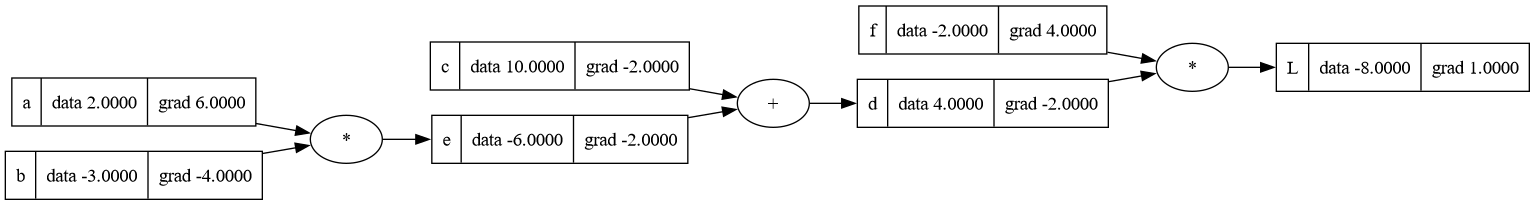

In [123]:
render_image(L)
#The idea fo all of this is to represent a simplified version of a forward pass, with the L being the final output and all the leaf nodes representing the weights. The next idea is to see how the different weights affect the final output, and that's what we will be doing by calculating the gradients.
#grad represents the value of the derivative of L (for example), respect to d, to f; and so on with the rest.
#We are not interested in calculating the gradient respect to the data because the data is fixed, so it will not be fascinating for us.

In [118]:
L.grad = 1.0 #manual definition of L gradient.

In [119]:
#We know that L = d * f, and we would like to know how much is dL / dd.
#Thanks to calculus we know that: (f(x + h) - f(x))/h when the limit tends to 0, as our function is d * f; ((f * d) + (f * h) - (f * d))/h => (f * h) / h => f; so the derivative of L respect to d is f.
#Symmetrically, dL/df would be d
f.grad = 4.0
d.grad = -2.0

In [120]:
#Now we want to know dL/dc and dL/de.
#We will first try to calculate dd/dc, we know d = c + e, so it is 1.0; the same applies to dd/de, which also is 1.0.
#To calculate the derivatives we are interested in, we will use the chain rule.
#We want : dL / dc = (dL / dd) * (dd / dc)
#We know: dL / dd and dd / dc
# Intuitive explanation is, if a car walks twice as fast as a bike, and the bike goes 4 times faster than a human walking; then the car is 8 times faster than the human walking.
#In this case, as dd/dc is 1.0; dL/dc = dL/dd = -2.0, the same applies to dL/de which will aslo be -2.0.
#The '+' node is like a route for the gradient, an extra step which doesn't affect the gradient change at all.
e.grad = -2.0
c.grad = -2.0

In [121]:
#dL / da = (dL / de) * (de / da), we apply the chain rule again; and as we know, dL/de = -2.0; we just have to calculate de/da.
#e = a * b; de/da = ((b * (a + h) - (a * b)) / h => a; so dL / da = b * -2.0 => dL / da = 6.0
#Symmetrically, we do the same for dL/db = -2.0 * a => dL/db = -4.0
a.grad = 6.0
b.grad = -4.0

In [122]:
#After having calculated all the gradients, if we wanted to increase the value of L, we would just have to go in the direction of the gradient.
#a.data += 0.01 * a.grad, this would be like a single step of optimization

In [61]:
def lol():

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f
    L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0 + h, label = 'f')
    L = d * f
    L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

#This is like a training cell, just so we can manually see how much each variable affects L.

3.9999999999995595


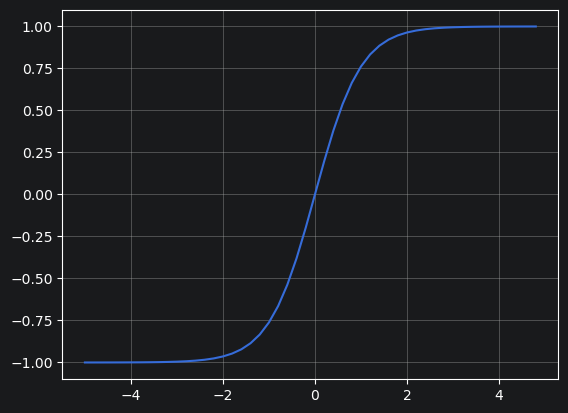

In [66]:
#Visualization of activation function tanh
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [129]:
#inputs, weights and bias. 2D neuron
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b') #bias so grads come out nice
#x1w1 + x2w2 + b
x1w1 = x1 * w1
x1w1.label = 'x1w1'
x2w2 = x2 * w2
x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b
n.label = 'n'
#now we generate the output with the activation function, which is tanh and we have to define it, as the only operations defined are addition and multiplication, and we cannot work with the tanh only with these 2 operations.
o = n.tanh() # We can also define o as the tanh but broken down with al the new operations we defined in the Value class.
o.label = 'o'
o.backward()

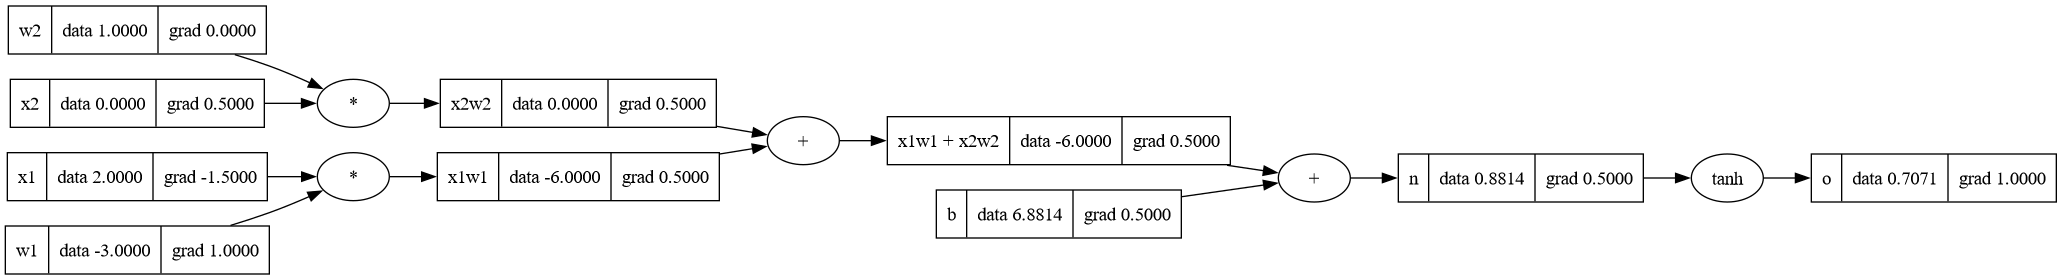

In [130]:
render_image(o)

In [100]:
#Now we start backpropagation
# o = tanh(n)
#do/dn = 1 - tanh(n) ** 2 => 1 - o**2 => 1- (0.7071)**2
#n.grad = 1 - o.data**2

In [101]:
#Now we have to calculate do/db and do/d(x1w1 + x2w2)
#do/db = do/dn * dn/db, as we commented before, the '+' operator works as a router, so its derivative is 1.0, then: do/db = do/dn = 0.5
#do/d(x1w1 + x2w2) = do/dn * do/d(x1w1 + x2w2), as in the previous case, gradient will also be 0.5
#b.grad = 0.5
#x1w1x2w2.grad = 0.5

In [102]:
#Now we have to calculate: do/dx1w1 and do/dx2w2; we already know that x1w1x2w2.grad = 0.5. (It was an adding operation, the gradient just routes)
#do/dx1w1 = do/d(x1w1 + x2w2) * d(x1w1 + x2w2)/dx1w1, we derive respect to x1w1, so it is 1.0
#do/dx2w2 = do/d(x1w1 + x2w2) * d(x1w1 + x2w2)/dx2w2, same here
#x1w1.grad = 0.5
#x2w2.grad = 0.5

In [103]:
#For the last one, we want to know: do/dx1, do/dw1, do/dx2, do/dw2. We know: x1w1.grad = 0.5 and x2w2.grad = 0.5
#do/dx1 = do/x1w1 * dx1w1/dx1
#do/dw1 = do/x1w1 * dx1w1/dw1
# #do/dx2 = do/x2w2 * dx2w2/dx2
# #do/dw2 = do/x2w2 * dx2w2/dw2
#x1.grad = x1w1.grad * w1.data
#w1.grad = x1w1.grad * x1.data
#x2.grad = x2w2.grad * w2.data
#w2.grad = x2w2.grad * x2.data

In [113]:
#This way, we have been able to calculate all the gradients automatically, the order is really important, as we need to have all the gradients of the dependencies to be able to calculate other gradients. This order is achieved with the topological sort.
#o.grad = 1
#o._backward()
#n._backward()
#b._backward()
#x1w1x2w2._backward()
#x1w1._backward()
#x2w2._backward()
#x1._backward()
#x2._backward()
#w1._backward()
#w2._backward()

In [131]:
#NOW WITH PYTORCH
import torch